In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import warnings

# Suppress all UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


traning_loss = []
accuracy = []


Using device: cpu


Generic Traing model

In [14]:
model_results = {}

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-5, name="Model"):
    """
    Generic training loop for regression tasks with validation.
    """
    # Move model to device (GPU or CPU)
    model = model.to(device)

    # Loss function for regression
    criterion = nn.MSELoss()

    # Optimizer (SGD with momentum)
    # optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    # regularazitaiton 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )


    print(f"\nTraining {name} for {epochs} epochs...")
    start_time = time.time()

    final_val_loss = 0.0

    model_results[name] = {
        "train_loss": [],
        "val_loss": [],
        "dir_acc": [],
        "mae": []
    }

    # all_y = []
    # for x, y in train_loader:
    #     all_y.append(y)
    # all_y = torch.cat(all_y)
    # print("Y min:", all_y.min().item())
    # print("Y max:", all_y.max().item())
    # print("Y NaN:", torch.isnan(all_y).sum().item())
    # print("Y Inf:", torch.isinf(all_y).sum().item())

    


    for epoch in range(epochs):
       # --- Training Phase ---
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs.squeeze(), y)
            loss.backward()
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            # print(f"Gradient norm: {total_norm:.4f}")
            optimizer.step()

            running_loss += loss.item()
            # break

        train_loss = running_loss / len(train_loader)
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        total = 0.0
        correct = 0.0
        mae = 0.0


        with torch.no_grad():
            all_preds   = []
            all_targets = []

            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs.squeeze(), y)
                val_loss += loss.item()
                mae += torch.mean(torch.abs(outputs - y)).item()
                # total += y.numel()
                # epsilon = 1e-8
                # this is numerica and it predicet the actual price of stock +- 30% the acutal closing
                # correct += ((torch.abs(outputs.squeeze() - y) / (y + epsilon)) < 0.3).sum().item()
                # Did prediction and actual agree on direction?
                # correct += ((outputs.squeeze() > 0) == (y > 0)).sum().item()
                # total += y.numel()
                all_preds.append(outputs.squeeze().cpu())
                all_targets.append(y.cpu())

            all_preds   = torch.cat(all_preds)
            all_targets = torch.cat(all_targets)

            pred_dir   = all_preds[1:] > all_preds[:-1]
            actual_dir = all_targets[1:] > all_targets[:-1]
            correct    = (pred_dir == actual_dir).float().sum().item()
            total      = len(actual_dir)


        final_val_loss = val_loss / len(val_loader)
        final_val_acc = 100 * correct / total
        final_mae = mae / len(val_loader)

        model_results[name]["train_loss"].append(train_loss)
        model_results[name]["val_loss"].append(final_val_loss)
        model_results[name]["dir_acc"].append(final_val_acc)
        model_results[name]["mae"].append(final_mae)

        print(f"  Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {final_val_loss:.4f} | dir Acc: {final_val_acc:.2f}% | MEA: {final_mae:.2f}")

    end_time = time.time()
    duration = end_time - start_time
    print(f"{name} - Final Accuracy: {final_val_acc:.2f}%, Time: {duration:.2f}s")

    return final_val_acc, final_val_loss, duration

Data preparation

In [5]:
# Load the dataset
dataset = load_dataset("Adilbai/stock-dataset")
df = dataset["train"].to_pandas()
print(df.columns)
# Basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique tickers: {df['Ticker'].nunique()}")

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50',
       'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Volatility', 'Price_Change', 'Price_Change_5d', 'High_Low_Ratio',
       'Open_Close_Ratio', 'Volume_SMA', 'Volume_Ratio', 'Close_lag_1',
       'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10',
       'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5',
       'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2',
       'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10',
       'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
       'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10',
       'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3',
       'Volatility_lag_5', 'Volatility_lag_10', 'Future_Return_1d',

In [6]:
new_df = pd.DataFrame(df[df["Ticker"] == 'AAPL'].tail(500))
new_df


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
49147,2023-06-30 00:00:00-04:00,189.730380,192.552119,189.364038,192.047180,85069600,0.0,0.0,AAPL,187.352176,...,1.0,-0.027633,0,0.0,0.000103,1,2.0,0.012785,1,2.0
49148,2023-07-03 00:00:00-04:00,191.859062,191.958076,189.859082,190.552155,31458200,0.0,0.0,AAPL,188.775928,...,1.0,-0.022758,0,0.0,0.006599,1,2.0,0.016367,1,2.0
49149,2023-07-05 00:00:00-04:00,189.670961,191.066972,188.730366,189.433334,46920300,0.0,0.0,AAPL,189.423441,...,2.0,-0.008153,0,1.0,0.019704,1,2.0,0.006533,1,2.0
49150,2023-07-06 00:00:00-04:00,187.958097,190.116494,187.324442,189.908569,45094300,0.0,0.0,AAPL,189.930365,...,1.0,-0.006621,0,1.0,0.006882,1,2.0,-0.003337,0,1.0
49151,2023-07-07 00:00:00-04:00,189.512554,190.760058,188.354154,188.789780,46778000,0.0,0.0,AAPL,190.146204,...,1.0,0.000052,1,2.0,0.006608,1,2.0,-0.045574,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49642,2025-06-23 00:00:00-04:00,201.630005,202.300003,198.960007,201.500000,55814300,0.0,0.0,AAPL,198.628000,...,1.0,0.000398,0,2.0,0.009438,0,2.0,0.005651,0,2.0
49643,2025-06-24 00:00:00-04:00,202.589996,203.440002,200.199997,200.300003,54064000,0.0,0.0,AAPL,199.004001,...,2.0,0.000398,0,2.0,0.009438,0,2.0,0.005651,0,2.0
49644,2025-06-25 00:00:00-04:00,201.449997,203.669998,200.619995,201.559998,39525700,0.0,0.0,AAPL,200.188000,...,1.0,0.000398,0,2.0,0.009438,0,2.0,0.005651,0,2.0
49645,2025-06-26 00:00:00-04:00,201.429993,202.639999,199.460007,201.000000,50799100,0.0,0.0,AAPL,201.072000,...,2.0,0.000398,0,2.0,0.009438,0,2.0,0.005651,0,2.0


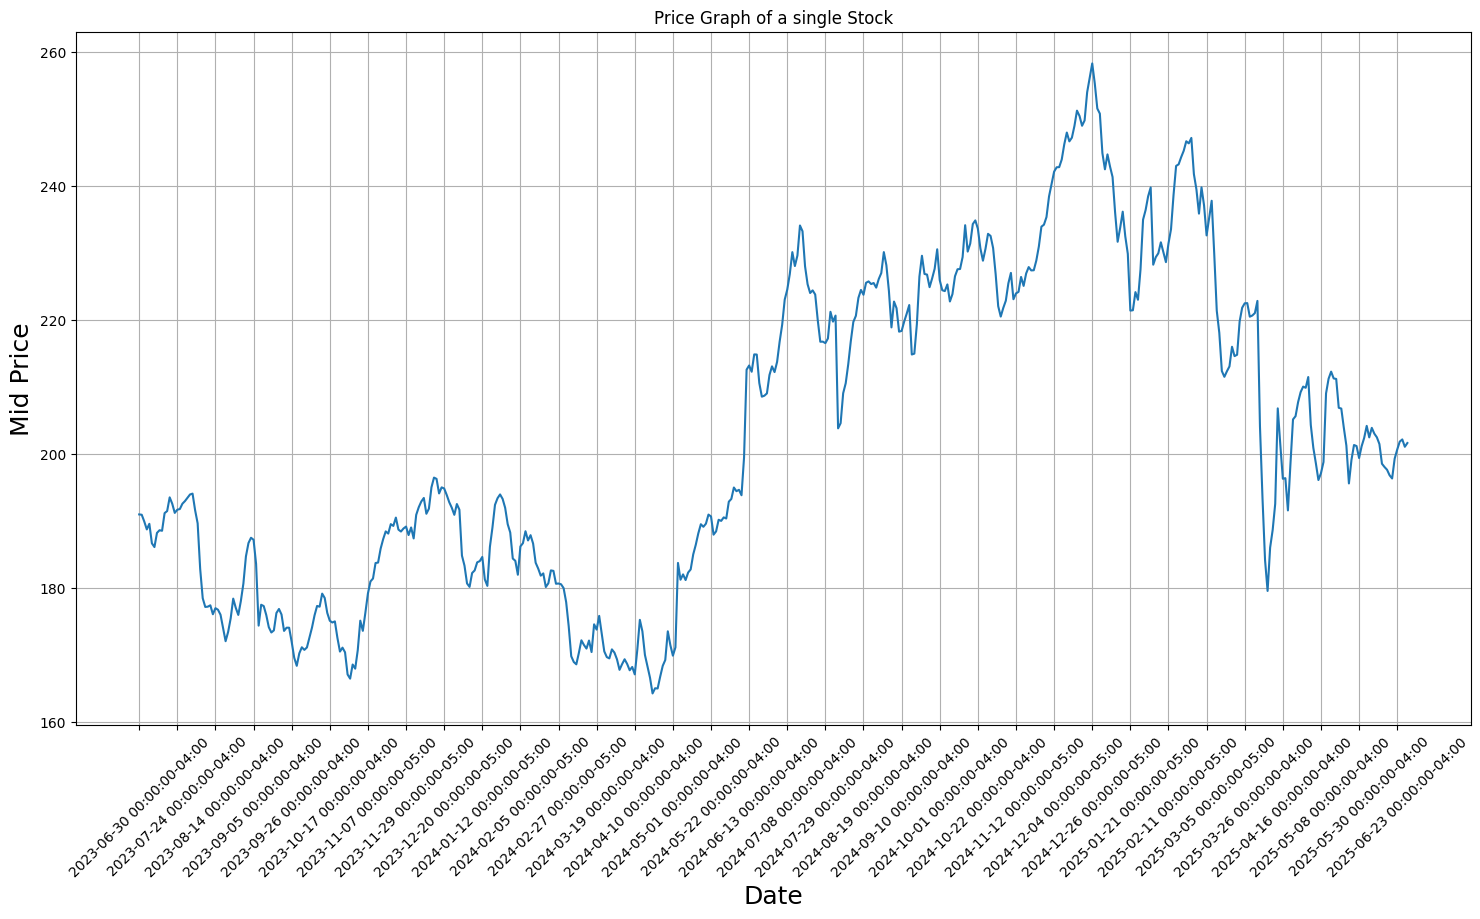

In [7]:
plt.figure(figsize = (18,9))
plt.plot(range(new_df.shape[0]),(new_df['Low']+new_df['High'])/2.0)
plt.xticks(range(0,new_df.shape[0],15),new_df['Date'].loc[::15],rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.title("Price Graph of a single Stock")
plt.grid(True)
plt.show()

In [8]:
# Sort by date for each ticker
df = df.sort_values(['Ticker', 'Date'])
# print(df)

# df['Return'] = df['Close'].pct_change()
# df['High_Return'] = (df['High'] - df['Close'].shift(1)) / df['Close'].shift(1)

# Only use numerical columns for prediction
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26',
    'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
    'BB_Width', 'BB_Position', 'Volatility',
    'Price_Change', 'High_Low_Ratio', 'Open_Close_Ratio',
    'Volume_SMA', 'Volume_Ratio',
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3',
    'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3',
    'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3',
    'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3'
]
print(len(features))

# for trends use this features
# ['SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26']

# ticker = df['Ticker'].unique()
# print(ticker)
# df_ticker = df[df['Ticker'] == ticker].reset_index(drop=True)

# tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'NVDA'] 
tickers = df["Ticker"].unique().tolist()
# all_dfs = []

# for ticker in tickers:
#     df_ticker = df[df['Ticker'] == ticker].reset_index(drop=True)
    
#     # Scale each ticker independently
#     scaler = MinMaxScaler()
#     df_ticker[features] = scaler.fit_transform(df_ticker[features])
    
#     all_dfs.append(df_ticker)

# # Combine all tickers into one training set
# df_combined = pd.concat(all_dfs).reset_index(drop=True)
# # print(df_ticker["Ticker"])

34


In [9]:

class StockDataset(Dataset):
    def __init__(self, df, features, seq_len=25, target_col='Close'):
        self.seq_len   = seq_len
        self.features  = features
        self.index     = []   # (ticker_array, start_idx) pairs

        self.data = {}
        for ticker, group in df.groupby('Ticker'):
            group = group.sort_values('Date').reset_index(drop=True)
            X = group[features].values.astype(np.float32)
            y = group[target_col].values.astype(np.float32)
            self.data[ticker] = (X, y)

            for i in range(seq_len, len(group)):
                self.index.append((ticker, i))   # just store a pointer

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        ticker, i = self.index[idx]
        X, y = self.data[ticker]
        seq    = torch.tensor(X[i - self.seq_len:i])
        target = torch.tensor(y[i])
        return seq, target

In [10]:
# Fit ONLY on train, transform all splits
def normalize_splits(train_df, val_df, test_df, features):
    all_train, all_val, all_test = [], [], []
    scalers = {}

    for ticker in train_df['Ticker'].unique():
        tr = train_df[train_df['Ticker'] == ticker].copy()
        va = val_df[val_df['Ticker'] == ticker].copy()
        te = test_df[test_df['Ticker'] == ticker].copy()

        scaler = RobustScaler()
        tr[features] = scaler.fit_transform(tr[features])   # fit on train only

        if len(va) > 0:
            va[features] = scaler.transform(va[features])   # transform only
        if len(te) > 0:
            te[features] = scaler.transform(te[features])   # transform only

        scalers[ticker] = scaler
        all_train.append(tr)
        all_val.append(va)
        all_test.append(te)

    train = pd.concat(all_train, ignore_index=True)
    val   = pd.concat(all_val,   ignore_index=True)
    test  = pd.concat(all_test,  ignore_index=True)

    return train, val, test, scalers


In [11]:
train_dfs, val_dfs, test_dfs = [], [], []

for ticker in tickers:
    df_ticker = df[df['Ticker'] == ticker].reset_index(drop=True)

    df_ticker['Target'] = (
        df_ticker['Close'].shift(-1) - df_ticker['Close']
    ) / (df_ticker['Close'] + 1e-8)
    df_ticker['Target'] = df_ticker['Target'].clip(-0.1, 0.1)

    df_ticker = df_ticker.dropna(subset=['Target']).reset_index(drop=True)
    
    # Split each ticker chronologically BEFORE scaling
    n         = len(df_ticker)
    train_end = int(0.7  * n)
    val_end   = int(0.85 * n)
    
    train_part = df_ticker.iloc[:train_end].copy()
    val_part   = df_ticker.iloc[train_end:val_end].copy()
    test_part  = df_ticker.iloc[val_end:].copy()
    

    # Scale each ticker independently — fit on train only
    scaler = MinMaxScaler()
    train_part[features] = scaler.fit_transform(train_part[features])
    val_part[features]   = scaler.transform(val_part[features])
    test_part[features]  = scaler.transform(test_part[features])
    
    train_dfs.append(train_part)
    val_dfs.append(val_part)
    test_dfs.append(test_part)

# Combine splits across all tickers
def split_by_date(df, val_start='2022-01-01', test_start='2023-01-01'):
    train = df[df['Date'] < val_start]
    val   = df[(df['Date'] >= val_start) & (df['Date'] < test_start)]
    test  = df[df['Date'] >= test_start]
    return train, val, test

train_df, val_df, test_df = split_by_date(df)

train_df, val_df, test_df, scalers = normalize_splits(train_df, val_df, test_df, features)


# Datasets and DataLoaders
seq_len = 25

train_dataset = StockDataset(train_df, features, seq_len)
val_dataset   = StockDataset(val_df,   features, seq_len)
test_dataset  = StockDataset(test_df,  features, seq_len)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers = 0)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


# print("NaN in train_df:", train_df[features].isna().sum().sum())
# print("Inf in train_df:", np.isinf(train_df[features].values).sum())

# sample_x, sample_y = train_dataset[0]
# print("X shape:", sample_x.shape)
# print("X min:", sample_x.min().item())
# print("X max:", sample_x.max().item())  # should be 0-1
# print("Y value:", sample_y.item()) 

# print(train_df[features].describe())

# print("Features not in df:", [f for f in features if f not in train_df.columns])
# print("\nFeature value ranges:")
# print(train_df[features].max()) 

Train: 170929, Val: 112096, Test: 296608


In [12]:
# store the result
results = {}

Simple 1D CNN for practices

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, seq_len=25, n_features=None, n_classes=1):
        if n_features is None:
            n_features = len(features)
        super(SimpleCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)

        # Block 2
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)

        # Block 3
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        self.relu        = nn.ReLU()
        self.drop_conv   = nn.Dropout(0.4)   # after conv blocks
        self.drop_fc     = nn.Dropout(0.5)   # after fc1
        
        self.pool = nn.MaxPool1d(kernel_size=2)
        # AdaptiveAvgPool — always outputs size 1, no size crashes
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.flatten     = nn.Flatten()

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, n_classes)

        # Weight initialization
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # [batch, seq_len, features] -> [batch, features, seq_len]
        x = x.permute(0, 2, 1)

        # Conv Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop_conv(x)
        x = self.pool(x) 

        # Conv Block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.drop_conv(x)
        x = self.pool(x)

        # Conv Block 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.drop_conv(x)
        x = self.pool(x)


        # Pool -> Flatten -> FC
        x = self.global_pool(x)   # [batch, 128, 1]
        x = self.flatten(x)       # [batch, 128]
        x = self.relu(self.fc1(x))
        x = self.drop_fc(x)
        return self.fc2(x)        # [batch, 1]

# Initialize and train our complex CNN
my_cnn = SimpleCNN()
params_cnn = sum(p.numel() for p in my_cnn.parameters())
print(f"SimpleCNN Total Parameters: {params_cnn:,}")
acc, loss, t = train_model(my_cnn, train_loader, val_loader, epochs=10, name="Simple CNN")
results['Simple CNN'] = {'dir_acc': acc, 'loss': loss, 'time': t, 'params': params_cnn}

SimpleCNN Total Parameters: 42,977

Training Simple CNN for 15 epochs...
  Epoch [1/15] | Train Loss: 0.4827 | Val Loss: 1.0606 | dir Acc: 50.65% | MEA: 0.74
  Epoch [2/15] | Train Loss: 0.1642 | Val Loss: 1.2631 | dir Acc: 50.90% | MEA: 0.81
  Epoch [3/15] | Train Loss: 0.1340 | Val Loss: 1.0962 | dir Acc: 50.78% | MEA: 0.76
  Epoch [4/15] | Train Loss: 0.1204 | Val Loss: 0.9690 | dir Acc: 50.62% | MEA: 0.72
  Epoch [5/15] | Train Loss: 0.1101 | Val Loss: 1.0901 | dir Acc: 50.47% | MEA: 0.75
  Epoch [6/15] | Train Loss: 0.1034 | Val Loss: 0.9471 | dir Acc: 50.38% | MEA: 0.71
  Epoch [7/15] | Train Loss: 0.0979 | Val Loss: 1.1892 | dir Acc: 50.53% | MEA: 0.79
  Epoch [8/15] | Train Loss: 0.0940 | Val Loss: 0.9844 | dir Acc: 50.51% | MEA: 0.72
  Epoch [9/15] | Train Loss: 0.0898 | Val Loss: 1.0223 | dir Acc: 50.38% | MEA: 0.74
  Epoch [10/15] | Train Loss: 0.0870 | Val Loss: 0.8948 | dir Acc: 50.51% | MEA: 0.69
  Epoch [11/15] | Train Loss: 0.0833 | Val Loss: 1.3406 | dir Acc: 50.44% | 

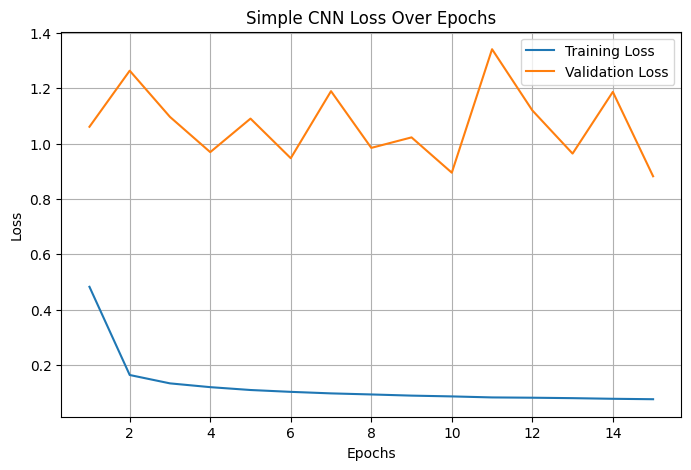

In [16]:
model_name = 'Simple CNN'

# print(model_results) 
train_loss = model_results[model_name]['train_loss']
val_loss = model_results[model_name]['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'{model_name} Loss Over Epochs')
plt.legend()
plt.grid(True)

plt.show()